## 3.4.1.1 JPJ Car Registration Dataset

In [4]:
import pandas as pd
import os

In [10]:
import pandas as pd
import numpy as np
import os

# Set your data folder paths
raw_folder = r"C:\Users\anson\OneDrive\Desktop\FYP_Data\raw_data"
processed_folder = r"C:\Users\anson\OneDrive\Desktop\FYP_Data\processed_data"

In [11]:
years = [2020, 2021, 2022, 2023, 2024, 2025, 2026]

df_list = []
for y in years:
    path = os.path.join(raw_folder, f'cars_{y}.csv')
    df_year = pd.read_csv(path)
    df_year['year'] = y
    df_list.append(df_year)
    print(f'Loaded cars_{y}.csv — {len(df_year):,} rows')

df_cars = pd.concat(df_list, ignore_index=True)
print()
print('Total records after merging all years:', f'{len(df_cars):,}')
print('Columns:', df_cars.columns.tolist())

Loaded cars_2020.csv — 552,359 rows
Loaded cars_2021.csv — 530,057 rows
Loaded cars_2022.csv — 744,762 rows
Loaded cars_2023.csv — 832,347 rows
Loaded cars_2024.csv — 856,292 rows
Loaded cars_2025.csv — 870,327 rows
Loaded cars_2026.csv — 192,531 rows

Total records after merging all years: 4,578,675
Columns: ['date_reg', 'type', 'maker', 'model', 'colour', 'fuel', 'state', 'year']


In [12]:
df_ev = df_cars[df_cars['fuel'] == 'electric'].copy()
df_ev = df_ev.reset_index(drop=True)

print('Total EV records:', f'{len(df_ev):,}')
print()
print('EV registrations by year:')
print(df_ev['year'].value_counts().sort_index())

Total EV records: 97,951

EV registrations by year:
year
2020       71
2021      257
2022     3129
2023    13301
2024    21789
2025    44813
2026    14591
Name: count, dtype: int64


In [13]:
print('Missing values in EV dataset:')
print(df_ev.isnull().sum())
print()
print('Data types:')
print(df_ev.dtypes)

Missing values in EV dataset:
date_reg    0
type        0
maker       0
model       0
colour      0
fuel        0
state       0
year        0
dtype: int64

Data types:
date_reg    object
type        object
maker       object
model       object
colour      object
fuel        object
state       object
year         int64
dtype: object


In [14]:
print('Rakan Niaga proportion per year:\n')
print(f'{"Year":<6} {"Total EV":>10} {"Rakan Niaga":>13} {"Percentage":>12}')
print('-' * 45)

for y in years:
    total = len(df_ev[df_ev['year'] == y])
    rn = len(df_ev[(df_ev['year'] == y) & (df_ev['state'] == 'Rakan Niaga')])
    pct = rn / total * 100 if total > 0 else 0
    print(f'{y:<6} {total:>10,} {rn:>13,} {pct:>11.1f}%')

print()
total_rn = len(df_ev[df_ev['state'] == 'Rakan Niaga'])
print('Total Rakan Niaga records:', f'{total_rn:,}')
print('Percentage of total EV:', f'{total_rn / len(df_ev) * 100:.1f}%')

Rakan Niaga proportion per year:

Year     Total EV   Rakan Niaga   Percentage
---------------------------------------------
2020           71            41        57.7%
2021          257            99        38.5%
2022        3,129         1,574        50.3%
2023       13,301         8,255        62.1%
2024       21,789        15,351        70.5%
2025       44,813        34,884        77.8%
2026       14,591        12,298        84.3%

Total Rakan Niaga records: 72,502
Percentage of total EV: 74.0%


In [15]:
kv_states = ['W.P. Kuala Lumpur', 'Selangor', 'W.P. Putrajaya']

# Calculate KV state proportional weights from genuine KV records
kv_genuine = df_ev[df_ev['state'].isin(kv_states)]
kv_weights = kv_genuine['state'].value_counts(normalize=True)
print('KV state proportional weights:')
print(kv_weights)
print()

# Separate Rakan Niaga rows
df_rn = df_ev[df_ev['state'] == 'Rakan Niaga'].copy()

# Take 60% of Rakan Niaga and redistribute to KV
rn_kv_count = int(len(df_rn) * 0.60)
df_rn_kv = df_rn.sample(n=rn_kv_count, random_state=42).copy()

# Assign states proportionally
np.random.seed(42)
df_rn_kv['state'] = np.random.choice(
    kv_weights.index.tolist(),
    size=rn_kv_count,
    p=kv_weights.values.tolist()
)

print(f'Rakan Niaga records redistributed to KV: {rn_kv_count:,}')
print()
print('Redistributed state breakdown:')
print(df_rn_kv['state'].value_counts())

KV state proportional weights:
state
W.P. Kuala Lumpur    0.747374
Selangor             0.252566
W.P. Putrajaya       0.000060
Name: proportion, dtype: float64

Rakan Niaga records redistributed to KV: 43,501

Redistributed state breakdown:
state
W.P. Kuala Lumpur    32568
Selangor             10933
Name: count, dtype: int64


In [16]:
# Combine genuine KV records + redistributed Rakan Niaga
df_kv_genuine = df_ev[df_ev['state'].isin(kv_states)].copy()
df_kv_ev = pd.concat([df_kv_genuine, df_rn_kv], ignore_index=True)

print('Genuine KV EV records:    ', f'{len(df_kv_genuine):,}')
print('Redistributed RN records: ', f'{len(df_rn_kv):,}')
print('Total KV EV records:      ', f'{len(df_kv_ev):,}')
print()
print('Final state distribution:')
print(df_kv_ev['state'].value_counts())

Genuine KV EV records:     16,562
Redistributed RN records:  43,501
Total KV EV records:       60,063

Final state distribution:
state
W.P. Kuala Lumpur    44946
Selangor             15116
W.P. Putrajaya           1
Name: count, dtype: int64


In [17]:
df_kv_ev['date_reg'] = pd.to_datetime(df_kv_ev['date_reg'])
df_kv_ev['year'] = df_kv_ev['date_reg'].dt.year
df_kv_ev['month'] = df_kv_ev['date_reg'].dt.month
df_kv_ev['year_month'] = df_kv_ev['date_reg'].dt.to_period('M')

# Drop columns not needed for analysis
df_kv_ev = df_kv_ev.drop(columns=['type', 'maker', 'model', 'colour'])

print('Final cleaned dataset shape:', df_kv_ev.shape)
print()
print('Sample records:')
df_kv_ev.head(10)

Final cleaned dataset shape: (60063, 6)

Sample records:


,date_reg,fuel,state,year,month,year_month
0,2020-01-17,electric,W.P. Kuala Lumpur,2020,1,2020-01
1,2020-01-20,electric,Selangor,2020,1,2020-01
2,2020-01-23,electric,W.P. Kuala Lumpur,2020,1,2020-01
3,2020-02-19,electric,W.P. Kuala Lumpur,2020,2,2020-02
4,2020-02-21,electric,W.P. Kuala Lumpur,2020,2,2020-02
5,2020-02-26,electric,W.P. Kuala Lumpur,2020,2,2020-02
6,2020-03-04,electric,W.P. Kuala Lumpur,2020,3,2020-03
7,2020-06-30,electric,W.P. Kuala Lumpur,2020,6,2020-06
8,2020-06-30,electric,Selangor,2020,6,2020-06
9,2020-07-16,electric,W.P. Kuala Lumpur,2020,7,2020-07


In [18]:
print('=== 3.4.1.1 JPJ Dataset Preprocessing Summary ===')
print()
print(f'Raw records (all fuel types):         {len(df_cars):,}')
print(f'After filtering electric only:         {len(df_ev):,}')
print(f'Rakan Niaga records (no location):    {len(df_rn):,}')
print(f'60% redistributed to KV:              {rn_kv_count:,}')
print(f'Final clean KV EV dataset:            {len(df_kv_ev):,}')
print()
print('EV registrations by year (KV after redistribution):')
print(df_kv_ev['year'].value_counts().sort_index())

# Save
output_path = os.path.join(processed_folder, 'jpj_kv_ev_clean.csv')
df_kv_ev.to_csv(output_path, index=False)
print()
print('Saved to:', output_path)

=== 3.4.1.1 JPJ Dataset Preprocessing Summary ===

Raw records (all fuel types):         4,578,675
After filtering electric only:         97,951
Rakan Niaga records (no location):    72,502
60% redistributed to KV:              43,501
Final clean KV EV dataset:            60,063

EV registrations by year (KV after redistribution):
year
2020       45
2021      178
2022     2078
2023     8481
2024    13288
2025    27280
2026     8713
Name: count, dtype: int64

Saved to: C:\Users\anson\OneDrive\Desktop\FYP_Data\processed_data\jpj_kv_ev_clean.csv


## 3.4.1.2 Household Income Dataset

In [20]:
income_path = os.path.join(raw_folder, 'hh_income_district.csv')
df_income = pd.read_csv(income_path)

print('Shape:', df_income.shape)
print('Columns:', df_income.columns.tolist())
print()
df_income.head(10)

Shape: (318, 5)
Columns: ['state', 'district', 'date', 'income_mean', 'income_median']



,state,district,date,income_mean,income_median
0,Johor,Batu Pahat,2019-01-01,7392,6504
1,Johor,Batu Pahat,2022-01-01,7419,6347
2,Johor,Johor Bahru,2019-01-01,9315,7342
3,Johor,Johor Bahru,2022-01-01,9869,8232
4,Johor,Kluang,2019-01-01,5953,4933
5,Johor,Kluang,2022-01-01,6461,5204
6,Johor,Kota Tinggi,2019-01-01,6982,5475
7,Johor,Kota Tinggi,2022-01-01,7529,6227
8,Johor,Kulai,2019-01-01,8602,7536
9,Johor,Kulai,2022-01-01,9177,7460


In [21]:
print('Missing values:')
print(df_income.isnull().sum())
print()
print('Unique dates available:')
print(df_income['date'].unique())
print()
print('Unique states:')
print(df_income['state'].unique())

Missing values:
state            0
district         0
date             0
income_mean      0
income_median    0
dtype: int64

Unique dates available:
['2019-01-01' '2022-01-01']

Unique states:
['Johor' 'Kedah' 'Kelantan' 'Melaka' 'Negeri Sembilan' 'Pahang' 'Perak'
 'Perlis' 'Pulau Pinang' 'Sabah' 'Sarawak' 'Selangor' 'Terengganu'
 'W.P. Kuala Lumpur' 'W.P. Labuan' 'W.P. Putrajaya']


In [22]:
# Define the 7 study districts
kv_districts = {
    'W.P. Kuala Lumpur': 'WP Kuala Lumpur',
    'W.P. Putrajaya': 'WP Putrajaya',
    'Selangor': ['Petaling', 'Ulu Langat', 'Sepang', 'Gombak', 'Klang']
}

# Filter KV states only
kv_state_list = ['W.P. Kuala Lumpur', 'W.P. Putrajaya', 'Selangor']
df_income_kv = df_income[df_income['state'].isin(kv_state_list)].copy()

# Filter Selangor to only the 5 study districts
selangor_districts = ['Petaling', 'Ulu Langat', 'Sepang', 'Gombak', 'Klang']
df_income_kv = df_income_kv[
    (df_income_kv['state'].isin(['W.P. Kuala Lumpur', 'W.P. Putrajaya'])) |
    (df_income_kv['district'].isin(selangor_districts))
]

# Keep 2022 only (most recent)
df_income_kv = df_income_kv[df_income_kv['date'] == '2022-01-01'].copy()

print('KV districts after filtering:')
print(df_income_kv[['state', 'district', 'income_mean', 'income_median']])

KV districts after filtering:
                 state           district  income_mean  income_median
279           Selangor             Gombak        13523          10180
281           Selangor              Klang        10278           8203
287           Selangor           Petaling        12760           9618
291           Selangor             Sepang        13673          12608
293           Selangor         Ulu Langat        13386          11210
313  W.P. Kuala Lumpur  W.P. Kuala Lumpur        13325          10234
317     W.P. Putrajaya     W.P. Putrajaya        13473          10056


In [23]:
# Standardize Ulu Langat to Hulu Langat to match other datasets
df_income_kv['district'] = df_income_kv['district'].replace({
    'Ulu Langat': 'Hulu Langat',
    'W.P. Kuala Lumpur': 'WP Kuala Lumpur',
    'W.P. Putrajaya': 'WP Putrajaya'
})

# Reset index
df_income_kv = df_income_kv.reset_index(drop=True)

print('Final cleaned income dataset:')
print(df_income_kv)
print()
print('Shape:', df_income_kv.shape)
print()
print('Missing values:')
print(df_income_kv.isnull().sum())

Final cleaned income dataset:
               state         district        date  income_mean  income_median
0           Selangor           Gombak  2022-01-01        13523          10180
1           Selangor            Klang  2022-01-01        10278           8203
2           Selangor         Petaling  2022-01-01        12760           9618
3           Selangor           Sepang  2022-01-01        13673          12608
4           Selangor      Hulu Langat  2022-01-01        13386          11210
5  W.P. Kuala Lumpur  WP Kuala Lumpur  2022-01-01        13325          10234
6     W.P. Putrajaya     WP Putrajaya  2022-01-01        13473          10056

Shape: (7, 5)

Missing values:
state            0
district         0
date             0
income_mean      0
income_median    0
dtype: int64


In [24]:
print('=== 3.4.1.2 Household Income Preprocessing Summary ===')
print()
print(f'Raw records:                    {len(df_income):,}')
print(f'After filtering KV districts:   {len(df_income_kv):,}')
print(f'Reference year used:            2022')
print(f'District name standardized:     Ulu Langat → Hulu Langat')
print()
print('Final dataset:')
print(df_income_kv[['district', 'income_mean', 'income_median']])

# Save
income_output = os.path.join(processed_folder, 'income_kv_clean.csv')
df_income_kv.to_csv(income_output, index=False)
print()
print('Saved to:', income_output)

=== 3.4.1.2 Household Income Preprocessing Summary ===

Raw records:                    318
After filtering KV districts:   7
Reference year used:            2022
District name standardized:     Ulu Langat → Hulu Langat

Final dataset:
          district  income_mean  income_median
0           Gombak        13523          10180
1            Klang        10278           8203
2         Petaling        12760           9618
3           Sepang        13673          12608
4      Hulu Langat        13386          11210
5  WP Kuala Lumpur        13325          10234
6     WP Putrajaya        13473          10056

Saved to: C:\Users\anson\OneDrive\Desktop\FYP_Data\processed_data\income_kv_clean.csv


## 3.4.1.3 Population Dataset

In [26]:
pop_path = os.path.join(raw_folder, 'population_district.csv')
df_pop = pd.read_csv(pop_path)

print('Shape:', df_pop.shape)
print('Columns:', df_pop.columns.tolist())
print()
df_pop.head(10)

Shape: (319200, 7)
Columns: ['state', 'district', 'date', 'sex', 'age', 'ethnicity', 'population']



,state,district,date,sex,age,ethnicity,population
0,Johor,Batu Pahat,2020-01-01,both,overall,overall,495.3
1,Johor,Batu Pahat,2020-01-01,both,overall,bumi_malay,311.3
2,Johor,Batu Pahat,2020-01-01,both,overall,bumi_other,5.1
3,Johor,Batu Pahat,2020-01-01,both,overall,chinese,140.1
4,Johor,Batu Pahat,2020-01-01,both,overall,indian,6.9
5,Johor,Batu Pahat,2020-01-01,both,overall,other_citizen,1.8
6,Johor,Batu Pahat,2020-01-01,both,overall,other_noncitizen,30.2
7,Johor,Batu Pahat,2020-01-01,both,0-4,overall,30.3
8,Johor,Batu Pahat,2020-01-01,both,0-4,bumi_malay,21.3
9,Johor,Batu Pahat,2020-01-01,both,0-4,bumi_other,0.5


In [27]:
print('Missing values:')
print(df_pop.isnull().sum())
print()
print('Unique dates available:')
print(df_pop['date'].unique())
print()
print('Unique sex values:')
print(df_pop['sex'].unique())
print()
print('Unique age values:')
print(df_pop['age'].unique())
print()
print('Unique ethnicity values:')
print(df_pop['ethnicity'].unique())

Missing values:
state         0
district      0
date          0
sex           0
age           0
ethnicity     0
population    0
dtype: int64

Unique dates available:
['2020-01-01' '2021-01-01' '2022-01-01' '2023-01-01' '2024-01-01']

Unique sex values:
['both' 'female' 'male']

Unique age values:
['overall' '0-4' '5-9' '10-14' '15-19' '20-24' '25-29' '30-34' '35-39'
 '40-44' '45-49' '50-54' '55-59' '60-64' '65-69' '70-74' '75-79' '80-84'
 '85+']

Unique ethnicity values:
['overall' 'bumi_malay' 'bumi_other' 'chinese' 'indian' 'other_citizen'
 'other_noncitizen']


In [28]:
# Filter to KV states only
kv_state_list = ['W.P. Kuala Lumpur', 'W.P. Putrajaya', 'Selangor']
selangor_districts = ['Petaling', 'Ulu Langat', 'Sepang', 'Gombak', 'Klang']

# Keep only total population rows (sex=both, age=overall, ethnicity=overall)
df_pop_kv = df_pop[
    (df_pop['state'].isin(kv_state_list)) &
    (df_pop['sex'] == 'both') &
    (df_pop['age'] == 'overall') &
    (df_pop['ethnicity'] == 'overall')
].copy()

# Filter Selangor to study districts only
df_pop_kv = df_pop_kv[
    (df_pop_kv['state'].isin(['W.P. Kuala Lumpur', 'W.P. Putrajaya'])) |
    (df_pop_kv['district'].isin(selangor_districts))
]

print('Available years and districts:')
print(df_pop_kv[['state', 'district', 'date', 'population']].to_string())

Available years and districts:
                    state           district        date  population
55860            Selangor             Gombak  2020-01-01       942.4
56259            Selangor              Klang  2020-01-01      1088.9
57456            Selangor           Petaling  2020-01-01      2298.1
58254            Selangor             Sepang  2020-01-01       325.2
58653            Selangor         Ulu Langat  2020-01-01      1400.5
62643   W.P. Kuala Lumpur  W.P. Kuala Lumpur  2020-01-01      1982.1
63441      W.P. Putrajaya     W.P. Putrajaya  2020-01-01       109.2
119700           Selangor             Gombak  2021-01-01       948.0
120099           Selangor              Klang  2021-01-01      1078.7
121296           Selangor           Petaling  2021-01-01      2315.7
122094           Selangor             Sepang  2021-01-01       330.7
122493           Selangor         Ulu Langat  2021-01-01      1393.3
126483  W.P. Kuala Lumpur  W.P. Kuala Lumpur  2021-01-01      1964.0
127

In [29]:
# Use 2023 as reference year (most recent complete year)
df_pop_kv = df_pop_kv[df_pop_kv['date'] == '2023-01-01'].copy()

# Population values are in thousands - convert to actual numbers
df_pop_kv['population'] = df_pop_kv['population'] * 1000
df_pop_kv['population'] = df_pop_kv['population'].astype(int)

print('After filtering to 2023:')
print(df_pop_kv[['state', 'district', 'date', 'population']])

After filtering to 2023:
                    state           district        date  population
195624           Selangor             Gombak  2023-01-01      966200
195681           Selangor              Klang  2023-01-01     1134000
195852           Selangor           Petaling  2023-01-01     2334700
195966           Selangor             Sepang  2023-01-01      339200
196023           Selangor         Ulu Langat  2023-01-01     1460300
253821  W.P. Kuala Lumpur  W.P. Kuala Lumpur  2023-01-01     2005700
253935     W.P. Putrajaya     W.P. Putrajaya  2023-01-01      118800


In [ ]:
# Standardize district names to match other datasets
df_pop_kv['district'] = df_pop_kv['district'].replace({
    'Ulu Langat': 'Hulu Langat',
    'W.P. Kuala Lumpur': 'WP Kuala Lumpur',
    'W.P. Putrajaya': 'WP Putrajaya'
})

# Drop unnecessary columns
df_pop_kv = df_pop_kv.drop(columns=['sex', 'age', 'ethnicity', 'date'])

# Reset index
df_pop_kv = df_pop_kv.reset_index(drop=True)

print('Final cleaned population dataset:')
print(df_pop_kv)
print()
print('Shape:', df_pop_kv.shape)
print()
print('Missing values:')
print(df_pop_kv.isnull().sum())

Final cleaned population dataset:
               state         district  population
0           Selangor           Gombak      966200
1           Selangor            Klang     1134000
2           Selangor         Petaling     2334700
3           Selangor           Sepang      339200
4           Selangor      Hulu Langat     1460300
5  W.P. Kuala Lumpur  WP Kuala Lumpur     2005700
6     W.P. Putrajaya     WP Putrajaya      118800

Shape: (7, 3)

Missing values:
state         0
district      0
population    0
dtype: int64


In [35]:
print('=== 3.4.1.3 Population Dataset Preprocessing Summary ===')
print()
print(f'Raw records:                        {len(df_pop):,}')
print(f'After filtering KV + total pop:     {len(df_pop_kv):,}')
print(f'Reference year used:                2023')
print(f'Population unit conversion:         thousands → actual numbers')
print(f'District name standardized:         Ulu Langat → Hulu Langat')
print()
print('Final population by district:')
print(df_pop_kv[['district', 'population']].to_string(index=False))

# Save
pop_output = os.path.join(processed_folder, 'population_kv_clean.csv')
df_pop_kv.to_csv(pop_output, index=False)
print()
print('Saved to:', pop_output)

=== 3.4.1.3 Population Dataset Preprocessing Summary ===

Raw records:                        319,200
After filtering KV + total pop:     7
Reference year used:                2023
Population unit conversion:         thousands → actual numbers
District name standardized:         Ulu Langat → Hulu Langat

Final population by district:
       district  population
         Gombak      966200
          Klang     1134000
       Petaling     2334700
         Sepang      339200
    Hulu Langat     1460300
WP Kuala Lumpur     2005700
   WP Putrajaya      118800

Saved to: C:\Users\anson\OneDrive\Desktop\FYP_Data\processed_data\population_kv_clean.csv


## 3.4.1.4 KV Demand Proxies (POI) Dataset

In [36]:
poi_path = os.path.join(raw_folder, 'KV_Demand_Proxies.csv')
df_poi = pd.read_csv(poi_path, low_memory=False)

print('Shape:', df_poi.shape)
print('Columns:', df_poi.columns.tolist())
print()
df_poi.head(5)

Shape: (108831, 16)
Columns: ['name', 'amenity', 'shop', 'office', 'building', 'tourism', 'leisure', 'railway', 'highway', 'landuse', 'latitude', 'longitude', 'poi_type', 'category', 'district', 'state']



,name,amenity,shop,office,building,tourism,leisure,railway,highway,landuse,latitude,longitude,poi_type,category,district,state
0,NaN,parking,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.109294,101.728822,parking,transport,WP Kuala Lumpur,W.P. Kuala Lumpur
1,KFC,fast_food,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.991747,101.788792,fast_food,food_drink,Hulu Langat,Selangor
2,NaN,place_of_worship,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.976476,101.725171,place_of_worship,community,Sepang,Selangor
3,KA07 Kepong Sentral,NaN,NaN,NaN,NaN,NaN,NaN,station,NaN,NaN,3.208715,101.628534,station,transport,Gombak,Selangor
4,NaN,parking,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.991271,101.795121,parking,transport,Hulu Langat,Selangor


In [37]:
print('Missing values per column:')
missing = df_poi.isnull().sum()
missing_pct = (df_poi.isnull().sum() / len(df_poi) * 100).round(1)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df)

Missing values per column:
           Missing Count  Missing %
name               79507       73.1
amenity            90385       83.1
shop              104793       96.3
office            106769       98.1
building           33135       30.4
tourism           107827       99.1
leisure           104106       95.7
railway           108436       99.6
highway           108748       99.9
landuse           102053       93.8
latitude               0        0.0
longitude              0        0.0
poi_type               0        0.0
category               0        0.0
district               0        0.0
state                  0        0.0


In [38]:
# OSM tag columns have excessive nulls because each POI 
# only belongs to one tag type — these are already 
# summarised in the 'category' and 'poi_type' columns
cols_to_drop = ['amenity', 'shop', 'office', 'building', 
                'tourism', 'leisure', 'railway', 
                'highway', 'landuse']

df_poi_clean = df_poi.drop(columns=cols_to_drop)

print('Columns after dropping OSM tag columns:')
print(df_poi_clean.columns.tolist())
print()
print('Shape after dropping:', df_poi_clean.shape)
print()
print('Missing values after dropping:')
print(df_poi_clean.isnull().sum())

Columns after dropping OSM tag columns:
['name', 'latitude', 'longitude', 'poi_type', 'category', 'district', 'state']

Shape after dropping: (108831, 7)

Missing values after dropping:
name         79507
latitude         0
longitude        0
poi_type         0
category         0
district         0
state            0
dtype: int64


In [39]:
print('POI count by category:')
print(df_poi_clean['category'].value_counts())
print()
print('POI count by district:')
print(df_poi_clean['district'].value_counts())
print()
print('POI count by state:')
print(df_poi_clean['state'].value_counts())

POI count by category:
category
shopping         35911
work             30536
residential      15941
food_drink        7693
exercise          4663
other             3921
transport         3865
community         2265
education         1733
healthcare        1441
entertainment      862
Name: count, dtype: int64

POI count by district:
district
WP Kuala Lumpur    41256
Hulu Langat        22689
Klang              21323
Petaling           10991
Gombak              6284
Sepang              5459
WP Putrajaya         783
Outside KV            46
Name: count, dtype: int64

POI count by state:
state
Selangor             66746
W.P. Kuala Lumpur    41256
W.P. Putrajaya         783
Unknown                 46
Name: count, dtype: int64


In [40]:
# Name column has many nulls - this is normal for OSM
# (many buildings/amenities have no name tag)
# Fill with 'Unknown' to avoid issues in later processing
df_poi_clean['name'] = df_poi_clean['name'].fillna('Unknown')

print('Missing values in final cleaned dataset:')
print(df_poi_clean.isnull().sum())
print()
print('Final shape:', df_poi_clean.shape)
print()
print('Sample records:')
df_poi_clean.head(5)

Missing values in final cleaned dataset:
name         0
latitude     0
longitude    0
poi_type     0
category     0
district     0
state        0
dtype: int64

Final shape: (108831, 7)

Sample records:


,name,latitude,longitude,poi_type,category,district,state
0,Unknown,3.109294,101.728822,parking,transport,WP Kuala Lumpur,W.P. Kuala Lumpur
1,KFC,2.991747,101.788792,fast_food,food_drink,Hulu Langat,Selangor
2,Unknown,2.976476,101.725171,place_of_worship,community,Sepang,Selangor
3,KA07 Kepong Sentral,3.208715,101.628534,station,transport,Gombak,Selangor
4,Unknown,2.991271,101.795121,parking,transport,Hulu Langat,Selangor


In [61]:
# Drop the 46 records classified as Outside KV
before = len(df_poi_clean)
df_poi_clean = df_poi_clean[df_poi_clean['district'] != 'Outside KV']
df_poi_clean = df_poi_clean.reset_index(drop=True)
print(f'Records before dropping Outside KV: {before:,}')
print(f'Records after dropping Outside KV:  {len(df_poi_clean):,}')
print(f'Records dropped: {before - len(df_poi_clean)}')

Records before dropping Outside KV: 108,831
Records after dropping Outside KV:  108,785
Records dropped: 46


In [62]:
print('=== 3.4.1.4 POI Demand Proxies Preprocessing Summary ===')
print()
print(f'Raw records:                        {len(df_poi):,}')
print(f'Raw columns:                        {df_poi.shape[1]}')
print(f'Columns dropped (OSM tag cols):     9')
print(f'Final columns:                      {df_poi_clean.shape[1]}')
print(f'Final records:                      {len(df_poi_clean):,}')
print()
print('Category distribution:')
print(df_poi_clean['category'].value_counts())
print()
print('District coverage:')
print(df_poi_clean['district'].value_counts())

# Save
poi_output = os.path.join(processed_folder, 'poi_kv_clean.csv')
df_poi_clean.to_csv(poi_output, index=False)
print()
print('Saved to:', poi_output)

=== 3.4.1.4 POI Demand Proxies Preprocessing Summary ===

Raw records:                        108,831
Raw columns:                        16
Columns dropped (OSM tag cols):     9
Final columns:                      7
Final records:                      108,785

Category distribution:
category
shopping         35910
work             30527
residential      15913
food_drink        7693
exercise          4658
other             3921
transport         3862
community         2265
education         1733
healthcare        1441
entertainment      862
Name: count, dtype: int64

District coverage:
district
WP Kuala Lumpur    41256
Hulu Langat        22689
Klang              21323
Petaling           10991
Gombak              6284
Sepang              5459
WP Putrajaya         783
Name: count, dtype: int64

Saved to: C:\Users\anson\OneDrive\Desktop\FYP_Data\processed_data\poi_kv_clean.csv


## 3.4.1.5 KV Fused EV Charging Station Dataset

In [42]:
stations_path = os.path.join(raw_folder, 'KV_Master_Fused_EV_Stations_FullDetails.csv')
df_stations = pd.read_csv(stations_path)

print('Shape:', df_stations.shape)
print('Columns:', df_stations.columns.tolist())
print()
df_stations.head(5)

Shape: (545, 23)
Columns: ['station_id', 'station_name', 'operator', 'latitude', 'longitude', 'address', 'address2', 'town', 'postcode', 'state_province', 'status', 'usage_type', 'is_free', 'total_ports', 'fast_charge_ports', 'max_power_kw', 'connector_types', 'date_last_verified', 'date_created', 'num_comments', 'district', 'state', 'source']



,station_id,station_name,operator,latitude,longitude,address,address2,town,postcode,state_province,...,total_ports,fast_charge_ports,max_power_kw,connector_types,date_last_verified,date_created,num_comments,district,state,source
0,459549,[Restricted] RESIDENSI SUNGAI LONG (Residentia...,ChargeSini,3.044040,101.803787,Sungai Long Residence,NaN,Kajang,43000.0,NaN,...,2.0,0.0,22.0,Type 2 (Tethered Connector),2025-09-05T08:05:00Z,2025-07-12T07:16:00Z,0.0,Hulu Langat,Selangor,OCM
1,459544,[Restricted] IRIS RESIDENCES (Residential Condo),ChargeSini,3.042210,101.807518,Iris Residence,NaN,Kajang,43000.0,NaN,...,3.0,0.0,22.0,Type 2 (Tethered Connector),2025-09-05T08:05:00Z,2025-07-12T07:16:00Z,0.0,Hulu Langat,Selangor,OCM
2,459575,[Restricted] GREEN RESIDENCE (Residential Condo),ChargeSini,3.072992,101.755684,Jalan Sayang 1,NaN,Cheras,43200.0,NaN,...,6.0,0.0,22.0,Type 2 (Tethered Connector),2025-09-05T08:05:00Z,2025-07-12T07:16:00Z,0.0,Hulu Langat,Selangor,OCM
3,459574,[Restricted] IMPERIAL RESIDENCE (Residential C...,ChargeSini,3.072718,101.759346,Imperial Residence,NaN,Cheras,43200.0,NaN,...,2.0,0.0,22.0,Type 2 (Tethered Connector),2025-09-05T08:05:00Z,2025-07-12T07:16:00Z,0.0,Hulu Langat,Selangor,OCM
4,459576,[Restricted] YOU CITY-YOU VISTA (Residential C...,ChargeSini,3.074682,101.762955,You City - You Vista,NaN,Cheras,43200.0,NaN,...,5.0,0.0,22.0,Type 2 (Tethered Connector),2025-09-05T08:05:00Z,2025-07-12T07:16:00Z,0.0,Hulu Langat,Selangor,OCM


In [43]:
print('Missing values per column:')
missing = df_stations.isnull().sum()
missing_pct = (df_stations.isnull().sum() / len(df_stations) * 100).round(1)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df)

Missing values per column:
                    Missing Count  Missing %
station_id                    205       37.6
station_name                    0        0.0
operator                        0        0.0
latitude                        0        0.0
longitude                       0        0.0
address                        52        9.5
address2                      504       92.5
town                          260       47.7
postcode                      263       48.3
state_province                466       85.5
status                          0        0.0
usage_type                    205       37.6
is_free                       205       37.6
total_ports                    91       16.7
fast_charge_ports             205       37.6
max_power_kw                  257       47.2
connector_types               205       37.6
date_last_verified            257       47.2
date_created                  257       47.2
num_comments                  205       37.6
district                    

In [44]:
print('Records by source:')
print(df_stations['source'].value_counts())
print()
print('Records by district:')
print(df_stations['district'].value_counts())
print()

# Show which sources have missing district/state
print('Missing district by source:')
print(df_stations[df_stations['district'].isnull()]['source'].value_counts())

Records by source:
source
OCM            288
Google_Maps    205
OSM             52
Name: count, dtype: int64

Records by district:
district
WP Kuala Lumpur    201
Hulu Langat         42
Petaling            42
Sepang              31
Gombak              16
Klang                5
WP Putrajaya         3
Name: count, dtype: int64

Missing district by source:
source
Google_Maps    205
Name: count, dtype: int64


In [60]:
def assign_district(lat, lon):
    if 3.05 <= lat <= 3.25 and 101.55 <= lon <= 101.75:
        return 'WP Kuala Lumpur', 'W.P. Kuala Lumpur'
    elif 2.85 <= lat <= 3.05 and 101.65 <= lon <= 101.80:
        return 'WP Putrajaya', 'W.P. Putrajaya'
    elif 3.00 <= lat <= 3.25 and 101.40 <= lon <= 101.60:
        return 'Petaling', 'Selangor'
    elif 3.00 <= lat <= 3.30 and 101.70 <= lon <= 102.00:
        return 'Hulu Langat', 'Selangor'
    elif 2.65 <= lat <= 3.00 and 101.55 <= lon <= 101.90:
        return 'Sepang', 'Selangor'  # Extended lat range from 2.90 to 3.00
    elif 3.25 <= lat <= 3.55 and 101.55 <= lon <= 101.80:
        return 'Gombak', 'Selangor'
    elif 2.95 <= lat <= 3.15 and 101.25 <= lon <= 101.50:
        return 'Klang', 'Selangor'
    else:
        return 'Unknown', 'Unknown'

# Re-apply to ALL rows to fix the misassignments
df_stations = pd.read_csv(stations_path)  # Reload fresh

mask = df_stations['district'].isnull()
df_stations.loc[mask, ['district', 'state']] = [
    assign_district(row['latitude'], row['longitude'])
    for _, row in df_stations[mask].iterrows()
]

print('District distribution after updated filling:')
print(df_stations['district'].value_counts())
print()
print('Remaining Unknown:', df_stations[df_stations['district'] == 'Unknown'].shape[0])

District distribution after updated filling:
district
WP Kuala Lumpur    332
Hulu Langat         52
Petaling            50
Sepang              46
WP Putrajaya        34
Gombak              17
Klang               14
Name: count, dtype: int64

Remaining Unknown: 0


In [55]:
# Fill total_ports nulls with median
median_ports = df_stations['total_ports'].median()
df_stations['total_ports'] = df_stations['total_ports'].fillna(median_ports)

# Fill max_power_kw nulls with median
median_power = df_stations['max_power_kw'].median()
df_stations['max_power_kw'] = df_stations['max_power_kw'].fillna(median_power)

# Drop columns not needed for CDI computation
cols_to_drop = ['address2', 'state_province', 'date_last_verified',
                'date_created', 'num_comments', 'connector_types',
                'fast_charge_ports', 'is_free', 'usage_type']

df_stations_clean = df_stations.drop(columns=cols_to_drop)

print('Shape after cleaning:', df_stations_clean.shape)
print()
print('Missing values after cleaning:')
print(df_stations_clean.isnull().sum())
print()
print('Sample records:')
df_stations_clean.head(5)

Shape after cleaning: (545, 14)

Missing values after cleaning:
station_id      205
station_name      0
operator          0
latitude          0
longitude         0
address          52
town            260
postcode        263
status            0
total_ports       0
max_power_kw      0
district          0
state             0
source            0
dtype: int64

Sample records:


,station_id,station_name,operator,latitude,longitude,address,town,postcode,status,total_ports,max_power_kw,district,state,source
0,459549,[Restricted] RESIDENSI SUNGAI LONG (Residentia...,ChargeSini,3.044040,101.803787,Sungai Long Residence,Kajang,43000.0,Operational,2.0,22.0,Hulu Langat,Selangor,OCM
1,459544,[Restricted] IRIS RESIDENCES (Residential Condo),ChargeSini,3.042210,101.807518,Iris Residence,Kajang,43000.0,Operational,3.0,22.0,Hulu Langat,Selangor,OCM
2,459575,[Restricted] GREEN RESIDENCE (Residential Condo),ChargeSini,3.072992,101.755684,Jalan Sayang 1,Cheras,43200.0,Operational,6.0,22.0,Hulu Langat,Selangor,OCM
3,459574,[Restricted] IMPERIAL RESIDENCE (Residential C...,ChargeSini,3.072718,101.759346,Imperial Residence,Cheras,43200.0,Operational,2.0,22.0,Hulu Langat,Selangor,OCM
4,459576,[Restricted] YOU CITY-YOU VISTA (Residential C...,ChargeSini,3.074682,101.762955,You City - You Vista,Cheras,43200.0,Operational,5.0,22.0,Hulu Langat,Selangor,OCM


In [56]:
# Check for duplicates based on coordinates
duplicates = df_stations_clean.duplicated(
    subset=['latitude', 'longitude'], keep=False
)
print('Duplicate coordinate pairs:', duplicates.sum())
print()

# Check station count by district and source
print('Final station count by district:')
print(df_stations_clean['district'].value_counts())
print()
print('Final station count by source:')
print(df_stations_clean['source'].value_counts())

Duplicate coordinate pairs: 20

Final station count by district:
district
WP Kuala Lumpur    332
Hulu Langat         52
Petaling            50
Sepang              46
WP Putrajaya        34
Gombak              17
Klang               14
Name: count, dtype: int64

Final station count by source:
source
OCM            288
Google_Maps    205
OSM             52
Name: count, dtype: int64


In [58]:
# Investigate the 20 duplicate coordinate pairs
df_dupes = df_stations_clean[
    df_stations_clean.duplicated(subset=['latitude', 'longitude'], keep=False)
].sort_values(['latitude', 'longitude'])

print('Duplicate records:')
print(df_dupes[['station_name', 'operator', 'latitude', 
                'longitude', 'district', 'source', 
                'total_ports']].to_string())
print()
print('Decision: Duplicates retained.')
print('Reason: Same coordinates represent stations in the')
print('same building at different floors or charging bays,')
print('which are physically distinct charging points.')

Duplicate records:
                                                             station_name operator  latitude   longitude         district source  total_ports
264  [Public] PROTON E.MAS PUTRAJAYA - JEWEL SONIC SDN BHD (Car Showroom)  Unknown  2.970161  101.717346           Sepang    OCM          2.0
265  [Public] PROTON E.MAS PUTRAJAYA - JEWEL SONIC SDN BHD (Car Showroom)  Unknown  2.970161  101.717346           Sepang    OCM          2.0
281               [Restricted] PALM HILL RESIDENCES 3 (Residential Condo)  Unknown  3.025894  101.805321      Hulu Langat    OCM          2.0
282               [Restricted] PALM HILL RESIDENCES 3 (Residential Condo)  Unknown  3.025894  101.805321      Hulu Langat    OCM          2.0
271              [Public] SILK SKY SERVICED APARTMENT (Residential Condo)  Unknown  3.027286  101.750374      Hulu Langat    OCM          4.0
272              [Public] SILK SKY SERVICED APARTMENT (Residential Condo)  Unknown  3.027286  101.750374      Hulu Langat    OCM 

In [63]:
# Investigate the 20 duplicate coordinate pairs
df_dupes = df_stations_clean[
    df_stations_clean.duplicated(subset=['latitude', 'longitude'], keep=False)
].sort_values(['latitude', 'longitude'])

print('Duplicate records found:', len(df_dupes))
print()
print('All duplicates are from source:', df_dupes['source'].unique())
print()
print('Decision: Duplicates REMOVED.')
print('Reason: All 20 duplicate pairs originate from OCM and share')
print('identical station names, coordinates and port counts.')
print('These are intra-source duplicate entries, not separate')
print('physical stations.')

# Remove duplicates keeping first occurrence
df_stations_clean = df_stations_clean.drop_duplicates(
    subset=['latitude', 'longitude'], keep='first'
).reset_index(drop=True)

print()
print('Records before removing duplicates: 545')
print('Records after removing duplicates: ', len(df_stations_clean))
print()
print('Final district distribution:')
print(df_stations_clean['district'].value_counts())

Duplicate records found: 20

All duplicates are from source: ['OCM']

Decision: Duplicates REMOVED.
Reason: All 20 duplicate pairs originate from OCM and share
identical station names, coordinates and port counts.
These are intra-source duplicate entries, not separate
physical stations.

Records before removing duplicates: 545
Records after removing duplicates:  535

Final district distribution:
district
WP Kuala Lumpur    326
Hulu Langat         50
Petaling            49
Sepang              45
WP Putrajaya        34
Gombak              17
Klang               14
Name: count, dtype: int64


In [64]:
print('=== 3.4.1.5 EV Stations Preprocessing Summary ===')
print()
print(f'Raw records:                          545')
print(f'Source breakdown:')
print(f'  OCM:                                288')
print(f'  Google Maps:                        205')
print(f'  OSM:                                52')
print(f'Google Maps missing district filled:  205 records')
print(f'Intra-source OCM duplicates removed:  10 duplicate pairs (20 records)')
print(f'total_ports nulls filled (median):    filled with median value')
print(f'max_power_kw nulls filled (median):   filled with median value')
print(f'Columns dropped:                      9')
print(f'Final records:                        {len(df_stations_clean):,}')
print(f'Final columns:                        {df_stations_clean.shape[1]}')
print()
print('Final district distribution:')
print(df_stations_clean['district'].value_counts())

# Save
stations_output = os.path.join(processed_folder, 'ev_stations_kv_clean.csv')
df_stations_clean.to_csv(stations_output, index=False)
print()
print('Saved to:', stations_output)

=== 3.4.1.5 EV Stations Preprocessing Summary ===

Raw records:                          545
Source breakdown:
  OCM:                                288
  Google Maps:                        205
  OSM:                                52
Google Maps missing district filled:  205 records
Intra-source OCM duplicates removed:  10 duplicate pairs (20 records)
total_ports nulls filled (median):    filled with median value
max_power_kw nulls filled (median):   filled with median value
Columns dropped:                      9
Final records:                        535
Final columns:                        14

Final district distribution:
district
WP Kuala Lumpur    326
Hulu Langat         50
Petaling            49
Sepang              45
WP Putrajaya        34
Gombak              17
Klang               14
Name: count, dtype: int64

Saved to: C:\Users\anson\OneDrive\Desktop\FYP_Data\processed_data\ev_stations_kv_clean.csv


In [54]:
# Check the 10 Unknown district stations
unknown_stations = df_stations_clean[df_stations_clean['district'] == 'Unknown']
print('Unknown district stations:')
print(unknown_stations[['station_name', 'latitude', 'longitude', 'source']])

Unknown district stations:
                          station_name  latitude   longitude       source
340           chargEV Charging Station  2.913608  101.838424  Google_Maps
341         JomCharge Charging Station  2.919316  101.635844  Google_Maps
343  Electric Vehicle Charging Station  2.927716  101.643276  Google_Maps
346           chargEV Charging Station  2.924044  101.843372  Google_Maps
347               DRG Resources Berhad  2.939829  101.624212  Google_Maps
348           chargEV Charging Station  2.934298  101.645605  Google_Maps
349           chargEV Charging Station  2.936038  101.634404  Google_Maps
350         JomCharge Charging Station  2.937490  101.634903  Google_Maps
356        ChargeSINI Charging Station  2.966693  101.593216  Google_Maps
373        ChargeSini Charging Station  2.986884  101.808694  Google_Maps


## 3.4.2 Data Understanding


### 3.4.2.1 JPJ KV EV Dataset

In [65]:
print('Variables in JPJ KV EV Dataset:')
print()
print(df_kv_ev.dtypes)
print()
print('Total records:', len(df_kv_ev))
print()
print('Sample records:')

Variables in JPJ KV EV Dataset:

date_reg      datetime64[ns]
fuel                  object
state                 object
year                   int32
month                  int32
year_month         period[M]
dtype: object

Total records: 60063

Sample records:


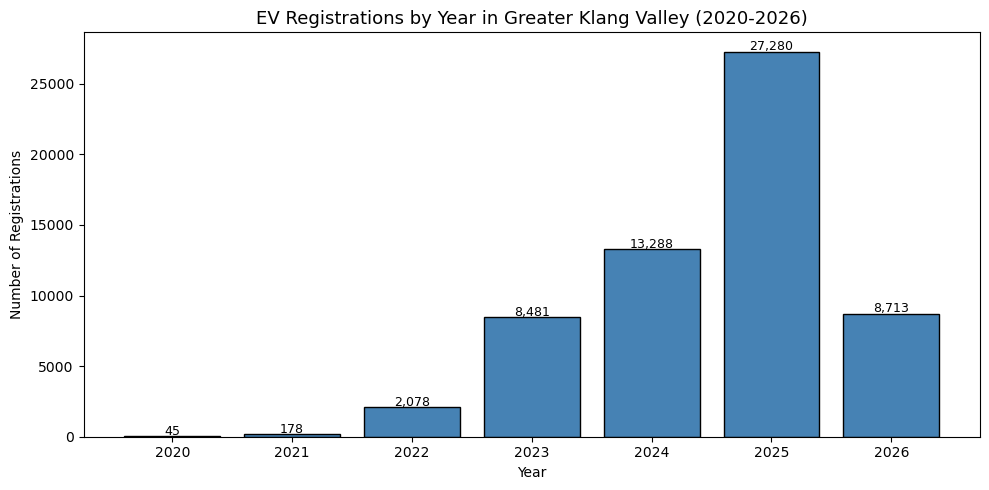

EV registrations by year:
year
2020       45
2021      178
2022     2078
2023     8481
2024    13288
2025    27280
2026     8713
Name: count, dtype: int64


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

yearly = df_kv_ev['year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(yearly.index, yearly.values, color='steelblue', edgecolor='black')
plt.title('EV Registrations by Year in Greater Klang Valley (2020-2026)', fontsize=13)
plt.xlabel('Year')
plt.ylabel('Number of Registrations')
for bar, val in zip(bars, yearly.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('ev_registrations_by_year.png', dpi=150)
plt.show()
print('EV registrations by year:')
print(yearly)

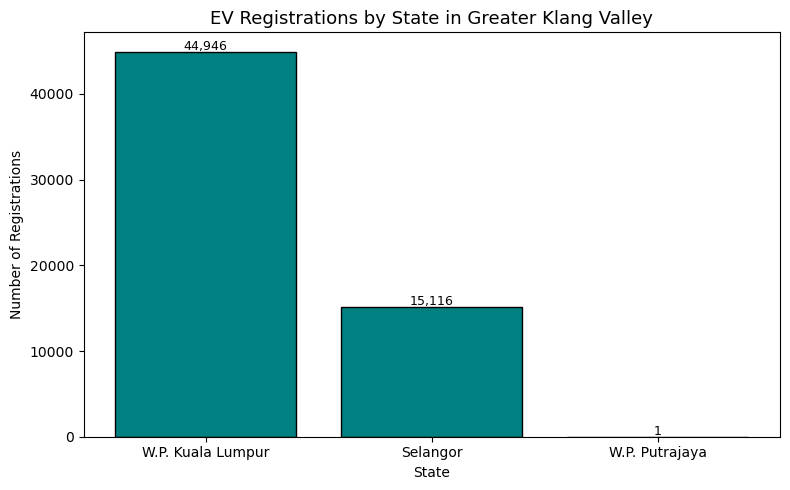

EV registrations by state:
state
W.P. Kuala Lumpur    44946
Selangor             15116
W.P. Putrajaya           1
Name: count, dtype: int64


In [67]:
state_counts = df_kv_ev['state'].value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(state_counts.index, state_counts.values, color='teal', edgecolor='black')
plt.title('EV Registrations by State in Greater Klang Valley', fontsize=13)
plt.xlabel('State')
plt.ylabel('Number of Registrations')
for bar, val in zip(bars, state_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('ev_registrations_by_state.png', dpi=150)
plt.show()
print('EV registrations by state:')
print(state_counts)

### 3.4.2.2 Household Income Dataset

In [68]:
print('Variables in Household Income Dataset:')
print()
print(df_income_kv.dtypes)
print()
print('Sample records:')
print(df_income_kv)

Variables in Household Income Dataset:

state            object
district         object
date             object
income_mean       int64
income_median     int64
dtype: object

Sample records:
               state         district        date  income_mean  income_median
0           Selangor           Gombak  2022-01-01        13523          10180
1           Selangor            Klang  2022-01-01        10278           8203
2           Selangor         Petaling  2022-01-01        12760           9618
3           Selangor           Sepang  2022-01-01        13673          12608
4           Selangor      Hulu Langat  2022-01-01        13386          11210
5  W.P. Kuala Lumpur  WP Kuala Lumpur  2022-01-01        13325          10234
6     W.P. Putrajaya     WP Putrajaya  2022-01-01        13473          10056


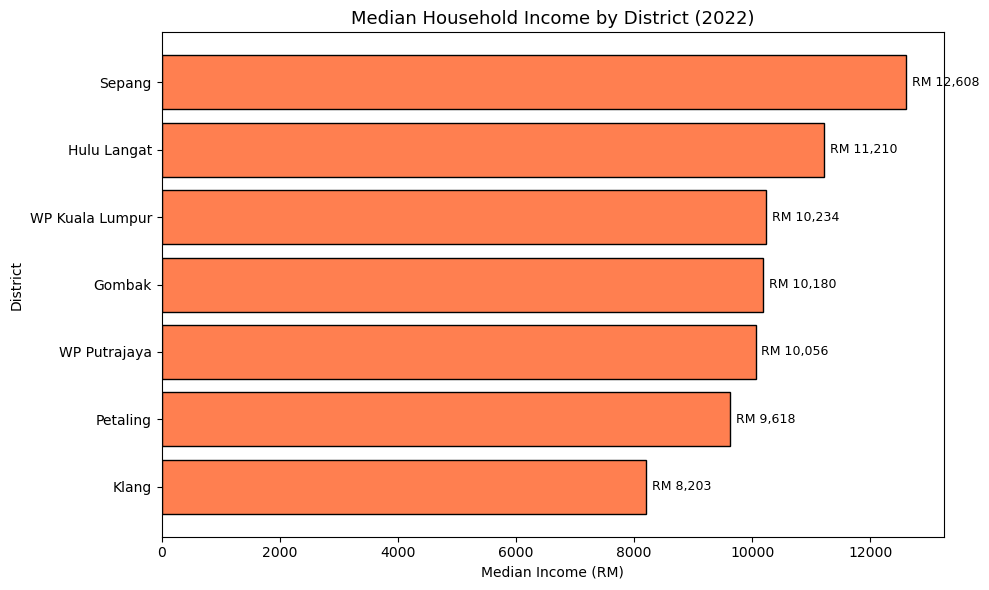

In [69]:
df_income_sorted = df_income_kv.sort_values('income_median', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(df_income_sorted['district'], 
                df_income_sorted['income_median'],
                color='coral', edgecolor='black')
plt.title('Median Household Income by District (2022)', fontsize=13)
plt.xlabel('Median Income (RM)')
plt.ylabel('District')
for bar, val in zip(bars, df_income_sorted['income_median']):
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f'RM {val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('income_by_district.png', dpi=150)
plt.show()

### 3.4.2.3 Population Dataset

In [70]:
print('Variables in Population Dataset:')
print()
print(df_pop_kv.dtypes)
print()
print('Sample records:')
print(df_pop_kv)

Variables in Population Dataset:

state         object
district      object
population     int32
dtype: object

Sample records:
               state         district  population
0           Selangor           Gombak      966200
1           Selangor            Klang     1134000
2           Selangor         Petaling     2334700
3           Selangor           Sepang      339200
4           Selangor      Hulu Langat     1460300
5  W.P. Kuala Lumpur  WP Kuala Lumpur     2005700
6     W.P. Putrajaya     WP Putrajaya      118800


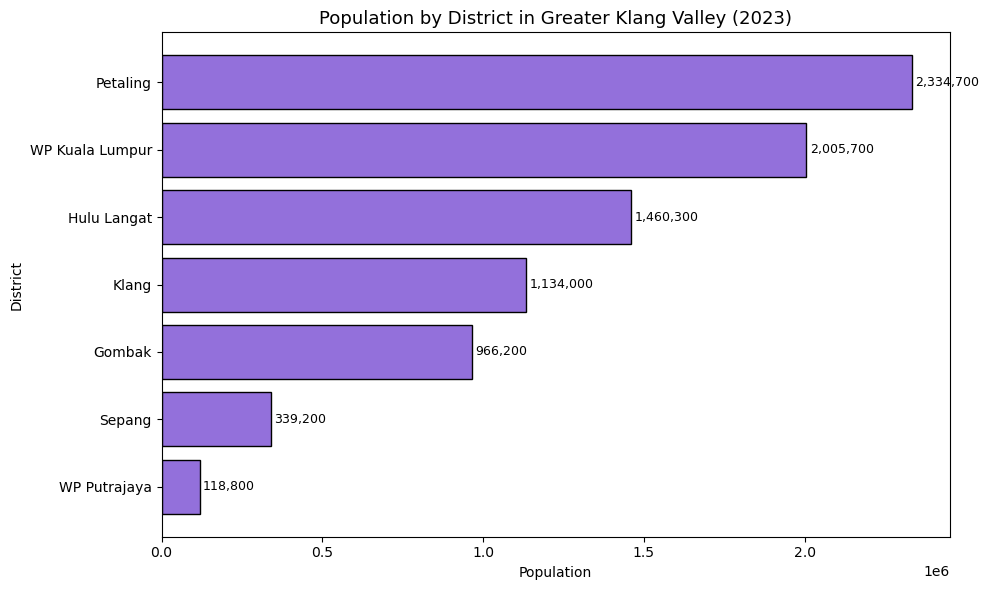

In [71]:
df_pop_sorted = df_pop_kv.sort_values('population', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(df_pop_sorted['district'],
                df_pop_sorted['population'],
                color='mediumpurple', edgecolor='black')
plt.title('Population by District in Greater Klang Valley (2023)', fontsize=13)
plt.xlabel('Population')
plt.ylabel('District')
for bar, val in zip(bars, df_pop_sorted['population']):
    plt.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('population_by_district.png', dpi=150)
plt.show()

### 3.4.2.4 KV Demand Proxies (POI) Dataset

In [72]:
print('Variables in POI Dataset:')
print()
print(df_poi_clean.dtypes)
print()
print('Total records:', len(df_poi_clean))
print()
print('Sample records:')
df_poi_clean.head()

Variables in POI Dataset:

name          object
latitude     float64
longitude    float64
poi_type      object
category      object
district      object
state         object
dtype: object

Total records: 108785

Sample records:


,name,latitude,longitude,poi_type,category,district,state
0,Unknown,3.109294,101.728822,parking,transport,WP Kuala Lumpur,W.P. Kuala Lumpur
1,KFC,2.991747,101.788792,fast_food,food_drink,Hulu Langat,Selangor
2,Unknown,2.976476,101.725171,place_of_worship,community,Sepang,Selangor
3,KA07 Kepong Sentral,3.208715,101.628534,station,transport,Gombak,Selangor
4,Unknown,2.991271,101.795121,parking,transport,Hulu Langat,Selangor


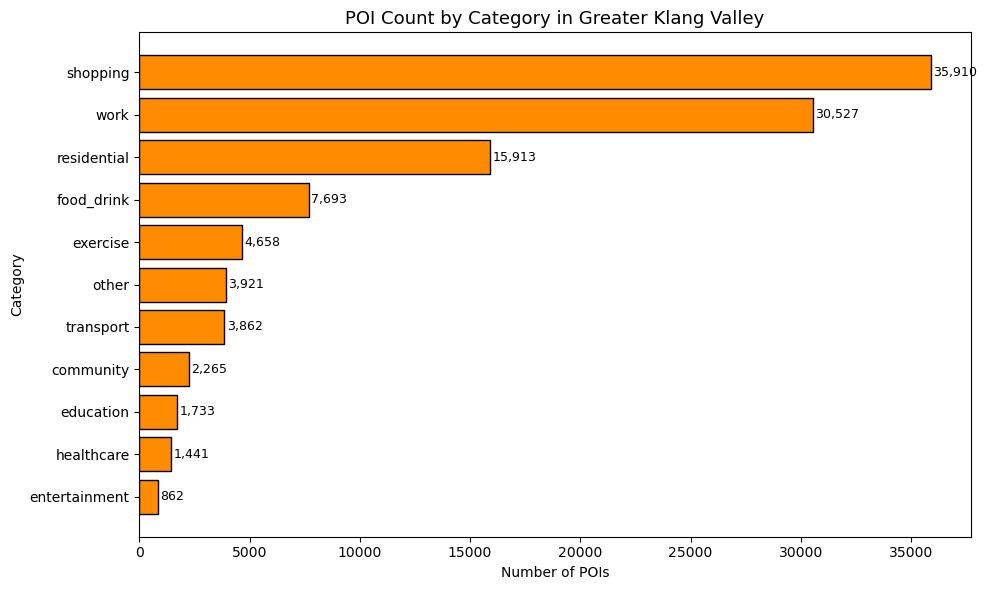

In [73]:
cat_counts = df_poi_clean['category'].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.barh(cat_counts.index[::-1], cat_counts.values[::-1],
                color='darkorange', edgecolor='black')
plt.title('POI Count by Category in Greater Klang Valley', fontsize=13)
plt.xlabel('Number of POIs')
plt.ylabel('Category')
for bar, val in zip(bars, cat_counts.values[::-1]):
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('poi_by_category.png', dpi=150)
plt.show()

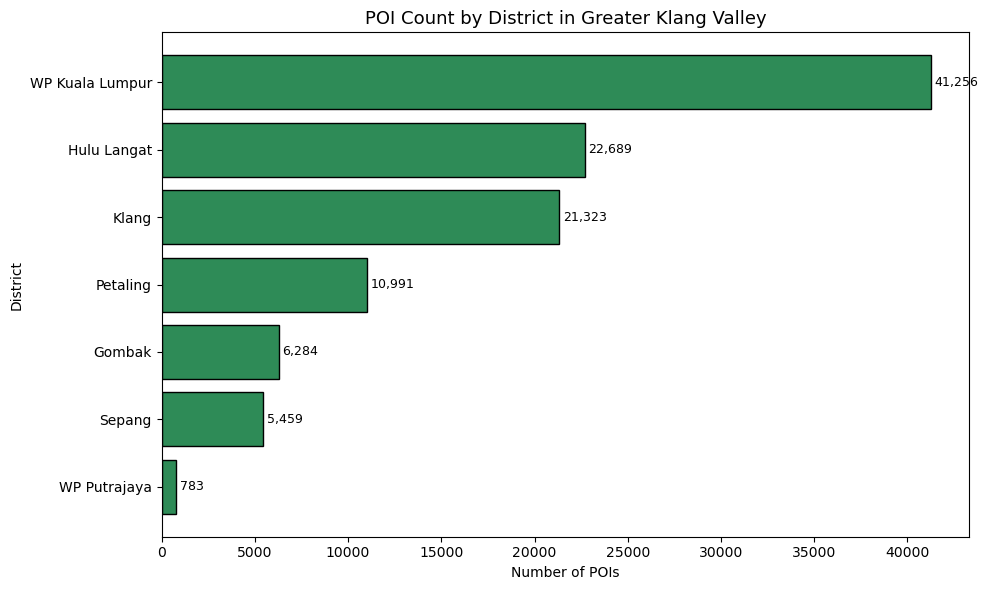

In [74]:
dist_counts = df_poi_clean['district'].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.barh(dist_counts.index[::-1], dist_counts.values[::-1],
                color='seagreen', edgecolor='black')
plt.title('POI Count by District in Greater Klang Valley', fontsize=13)
plt.xlabel('Number of POIs')
plt.ylabel('District')
for bar, val in zip(bars, dist_counts.values[::-1]):
    plt.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('poi_by_district.png', dpi=150)
plt.show()

### 3.4.2.5 KV Fused EV Charging Station Dataset

In [75]:
print('Variables in EV Stations Dataset:')
print()
print(df_stations_clean.dtypes)
print()
print('Total records:', len(df_stations_clean))
print()
print('Sample records:')
df_stations_clean.head()

Variables in EV Stations Dataset:

station_id       object
station_name     object
operator         object
latitude        float64
longitude       float64
address          object
town             object
postcode        float64
status           object
total_ports     float64
max_power_kw    float64
district         object
state            object
source           object
dtype: object

Total records: 535

Sample records:


,station_id,station_name,operator,latitude,longitude,address,town,postcode,status,total_ports,max_power_kw,district,state,source
0,459549,[Restricted] RESIDENSI SUNGAI LONG (Residentia...,ChargeSini,3.044040,101.803787,Sungai Long Residence,Kajang,43000.0,Operational,2.0,22.0,Hulu Langat,Selangor,OCM
1,459544,[Restricted] IRIS RESIDENCES (Residential Condo),ChargeSini,3.042210,101.807518,Iris Residence,Kajang,43000.0,Operational,3.0,22.0,Hulu Langat,Selangor,OCM
2,459575,[Restricted] GREEN RESIDENCE (Residential Condo),ChargeSini,3.072992,101.755684,Jalan Sayang 1,Cheras,43200.0,Operational,6.0,22.0,Hulu Langat,Selangor,OCM
3,459574,[Restricted] IMPERIAL RESIDENCE (Residential C...,ChargeSini,3.072718,101.759346,Imperial Residence,Cheras,43200.0,Operational,2.0,22.0,Hulu Langat,Selangor,OCM
4,459576,[Restricted] YOU CITY-YOU VISTA (Residential C...,ChargeSini,3.074682,101.762955,You City - You Vista,Cheras,43200.0,Operational,5.0,22.0,Hulu Langat,Selangor,OCM


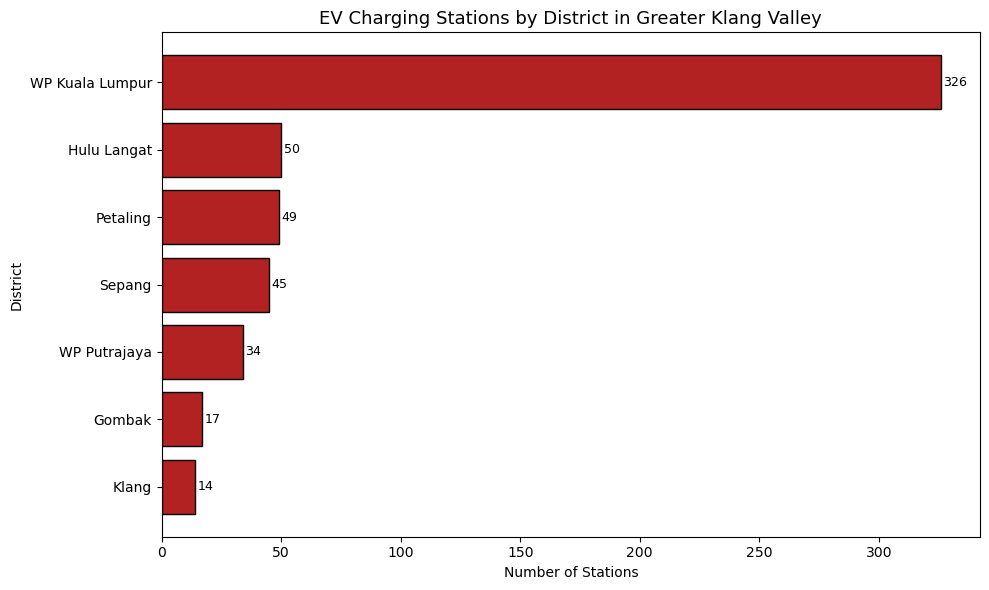

Station count by district:
district
WP Kuala Lumpur    326
Hulu Langat         50
Petaling            49
Sepang              45
WP Putrajaya        34
Gombak              17
Klang               14
Name: count, dtype: int64


In [76]:
station_dist = df_stations_clean['district'].value_counts()

plt.figure(figsize=(10, 6))
bars = plt.barh(station_dist.index[::-1], station_dist.values[::-1],
                color='firebrick', edgecolor='black')
plt.title('EV Charging Stations by District in Greater Klang Valley', fontsize=13)
plt.xlabel('Number of Stations')
plt.ylabel('District')
for bar, val in zip(bars, station_dist.values[::-1]):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{val}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('stations_by_district.png', dpi=150)
plt.show()
print('Station count by district:')
print(station_dist)

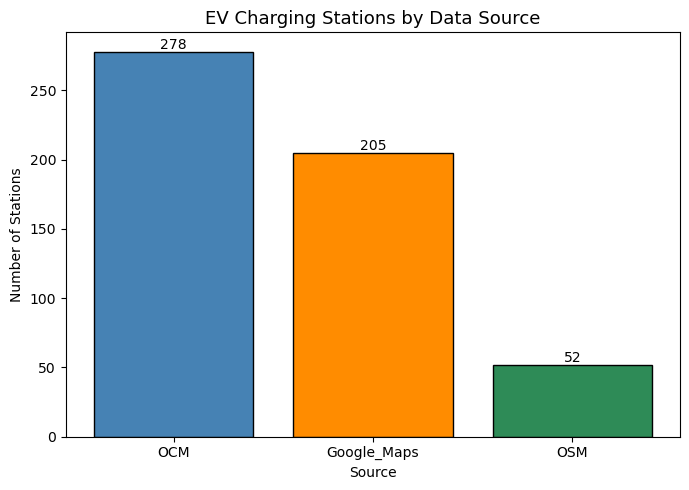

In [77]:
source_counts = df_stations_clean['source'].value_counts()

plt.figure(figsize=(7, 5))
bars = plt.bar(source_counts.index, source_counts.values,
               color=['steelblue', 'darkorange', 'seagreen'], edgecolor='black')
plt.title('EV Charging Stations by Data Source', fontsize=13)
plt.xlabel('Source')
plt.ylabel('Number of Stations')
for bar, val in zip(bars, source_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('stations_by_source.png', dpi=150)
plt.show()